In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import optuna

In [87]:
img = imread('../img/test_colorbar.png')

img.shape

(41, 1060, 4)

In [88]:
arr = img[20:30].mean(axis=0)

In [89]:
def extract_colormap(arr, step, offset):
    offset = offset % step
    if offset > 0:
        offset -= step
    x = np.arange(arr.shape[0])
    bin_edges = np.arange(x.min() + offset, x.max() + step, step)

    bin_indices = np.digitize(x, bins=bin_edges) - 1
    arr_broadcasted = np.zeros_like(arr)
    color_sequence = []
    for i in bin_indices:
        mask = bin_indices == i
        if not np.any(mask):
            continue
        mean_color = arr[mask].mean(axis=0)
        arr_broadcasted[mask] = mean_color
        color_sequence.append(mean_color)
    return arr_broadcasted, bin_edges, color_sequence

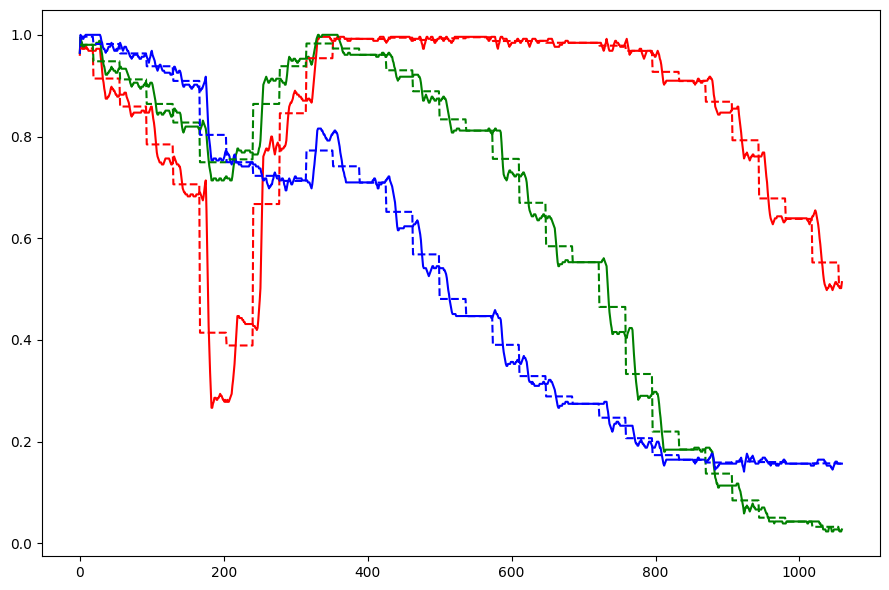

In [90]:
step = 37
offset = 19

arr_broadcasted, bin_edges, color_sequence = extract_colormap(arr, step, offset)

plt.close(1)
fig, ax = plt.subplots(num=1, figsize=(9,6))

plt.plot(arr[:,0], label='R', color='red')
plt.plot(arr[:,1], label='G', color='green')
plt.plot(arr[:,2], label='B', color='blue')

plt.plot(arr_broadcasted[:,0], label='R (binned)', color='red', linestyle='--')
plt.plot(arr_broadcasted[:,1], label='G (binned)', color='green', linestyle='--')
plt.plot(arr_broadcasted[:,2], label='B (binned)', color='blue', linestyle='--')

fig.tight_layout()

In [109]:
min_step = 10
max_step = 50
regularization = 1e-3

def objective(trial):
    step = trial.suggest_float('step', min_step, max_step)
    offset = trial.suggest_float('offset', 0, step)
    arr_broadcasted, bin_edges, color_sequence = extract_colormap(arr, step, offset)
    rmse = np.sqrt(np.mean((arr - arr_broadcasted) ** 2))
    return rmse + regularization * len(bin_edges)

study = optuna.create_study(direction='minimize')

[I 2026-05-28 14:16:38,594] A new study created in memory with name: no-name-e202b028-9aaf-4975-92ac-174411a189a2


In [110]:
study.optimize(objective, n_trials=100)

[I 2026-05-28 14:16:40,830] Trial 0 finished with value: 0.09483293443918228 and parameters: {'step': 13.780708791405395, 'offset': 6.3052593592147375}. Best is trial 0 with value: 0.09483293443918228.


[I 2026-05-28 14:16:40,848] Trial 1 finished with value: 0.05383956432342529 and parameters: {'step': 40.12194503790793, 'offset': 11.314748915353926}. Best is trial 1 with value: 0.05383956432342529.
[I 2026-05-28 14:16:40,863] Trial 2 finished with value: 0.06561940163373947 and parameters: {'step': 37.06407485124929, 'offset': 8.727564928824574}. Best is trial 1 with value: 0.05383956432342529.
[I 2026-05-28 14:16:40,876] Trial 3 finished with value: 0.10877469182014465 and parameters: {'step': 11.233269166281268, 'offset': 8.315949747404982}. Best is trial 1 with value: 0.05383956432342529.
[I 2026-05-28 14:16:40,889] Trial 4 finished with value: 0.0530497245490551 and parameters: {'step': 35.923587657820455, 'offset': 32.82369818603272}. Best is trial 4 with value: 0.0530497245490551.
[I 2026-05-28 14:16:40,903] Trial 5 finished with value: 0.06569162756204605 and parameters: {'step': 25.184593645632866, 'offset': 7.114972411801276}. Best is trial 4 with value: 0.0530497245490551.

In [111]:
study.best_params

{'step': 36.810580583992135, 'offset': 32.94611418181043}

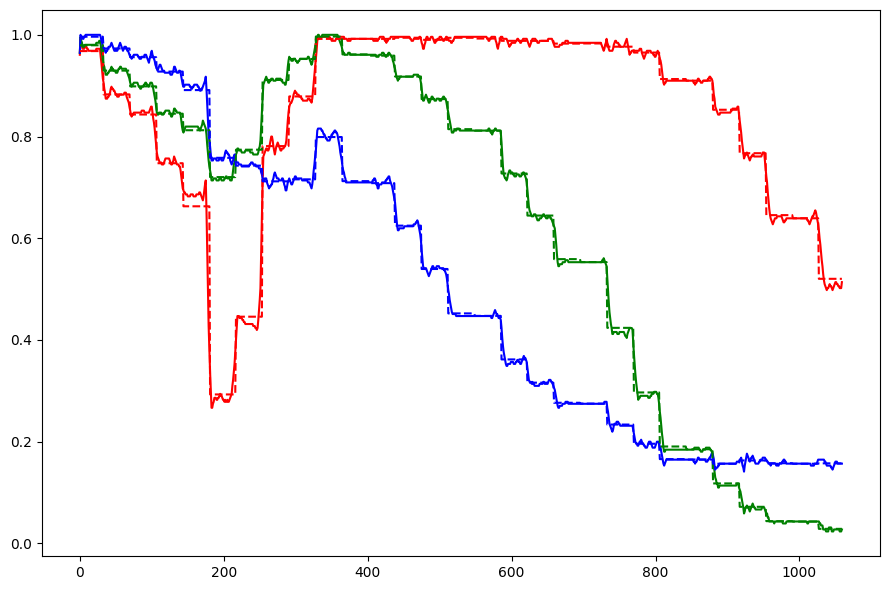

In [112]:
step = study.best_params['step']
offset = study.best_params['offset']

arr_broadcasted, bin_edges, color_sequence = extract_colormap(arr, step, offset)

plt.close(1)
fig, ax = plt.subplots(num=1, figsize=(9,6))

plt.plot(arr[:,0], label='R', color='red')
plt.plot(arr[:,1], label='G', color='green')
plt.plot(arr[:,2], label='B', color='blue')

plt.plot(arr_broadcasted[:,0], label='R (binned)', color='red', linestyle='--')
plt.plot(arr_broadcasted[:,1], label='G (binned)', color='green', linestyle='--')
plt.plot(arr_broadcasted[:,2], label='B (binned)', color='blue', linestyle='--')

fig.tight_layout()

In [113]:
# print color sequence as hex codes
print('colors = [')
for color in color_sequence:
    print('\t"#{:02x}{:02x}{:02x}",'.format(int(color[0]*255), int(color[1]*255), int(color[2]*255)))
print(']')

colors = [
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#f6f9fe",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#e1edf8",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7e5f3",
	"#d7